# Pet Store E-commerce Sales Analysis

이 프로젝트는 반려동물 용품 쇼핑몰의 가상의 판매 데이터를 분석하여
매출 추이와 인기 상품을 파악하는 것을 목표로 합니다.

## Project Objectives

- 월별 매출 추이 분석
- 상품별 매출 비교
- 상품 판매량 분석
- 일별 주문 패턴 분석

In [ ]:
import pandas as pd
import random
from datetime import datetime, timedelta
import matplotlib.pyplot as plt

## Data Generation

실제 쇼핑몰 데이터를 대신하여 Pytion을 이용해 가상의 주문 데이터를 생성합니다.

In [ ]:
products = {
    "Dog Snack": 5000,
    "Dog Toy": 7000,
    "Dog Shampoo": 12000,
    "Dog Leash": 15000,
    "Dog Food": 20000
}

data = []
start_date = datetime(2024, 1, 1)

for i in range(200):
    product_name = random.choice(list(products.keys()))
    price = products[product_name]
    quantity = random.randint(1, 5)
    order_date = start_date + timedelta(days=random.randint(0, 89))

    data.append([
        i + 1,
        order_date,
        product_name,
        price,
        quantity
    ])

df = pd.DataFrame(data, columns=[
    "order_id",
    "order_date",
    "product_name",
    "price",
    "quantity"
])

df.head()

,order_id,order_date,product_name,price,quantity
0,1,2024-03-30,Dog Food,20000,3
1,2,2024-02-19,Dog Toy,7000,4
2,3,2024-01-07,Dog Leash,15000,1
3,4,2024-01-13,Dog Food,20000,2
4,5,2024-01-16,Dog Leash,15000,3


## Data Preprocessing

매출(sales) 컬럼을 생성하고 날짜 데이터를 정리합니다.

In [ ]:
df["order_date"] = pd.to_datetime(df["order_date"])
df["sales"] = df["price"] * df["quantity"]

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   order_id      200 non-null    int64         
 1   order_date    200 non-null    datetime64[us]
 2   product_name  200 non-null    str           
 3   price         200 non-null    int64         
 4   quantity      200 non-null    int64         
 5   sales         200 non-null    int64         
dtypes: datetime64[us](1), int64(4), str(1)
memory usage: 9.5 KB


In [7]:
df.to_csv("../data/ecommerce_sales.csv", index=False)
print("CSV saved successfully.")

CSV saved successfully.


## Exploratory Data Anaysis (EDA)

데이터의 전반적인 특성과 매출 패턴을 탐색합니다.

In [8]:
total_sales = df["sales"].sum()
avg_order_value = df["sales"].mean()
total_orders = df["order_id"].count()
best_product = df.groupby("product_name")["sales"].sum().idxmax()

print("Total Sales:", total_sales)
print("Average Order Value:", round(avg_order_value, 2))
print("Total Orders:", total_orders)
print("Best Selling Product:", best_product)

Total Sales: 6937000
Average Order Value: 34685.0
Total Orders: 200
Best Selling Product: Dog Food


### Monthly Sales Trend

월별 매출을 집계하여 시간에 따른 매출 변화를 확인합니다.

In [9]:
monthly_sales = df.groupby(
    df["order_date"].dt.to_period("M")
)["sales"].sum()

monthly_sales

order_date
2024-01    2553000
2024-02    2380000
2024-03    2004000
Freq: M, Name: sales, dtype: int64

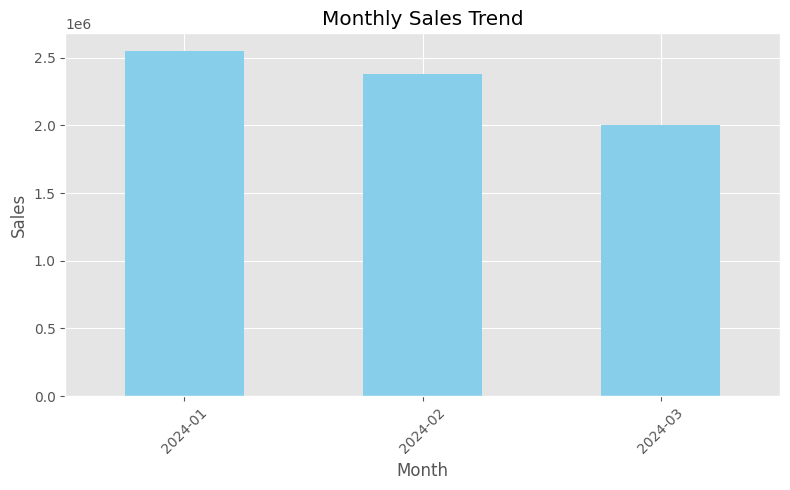

In [19]:
monthly_sales.plot(
    kind="bar",
    figsize=(8,5),
    color="skyblue"
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")

plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig("../images/monthly_sales.png")

plt.show()

### Sales by Product

상품별 매출 기여도를 분석합니다.

In [11]:
product_sales = df.groupby("product_name")["sales"].sum().sort_values(ascending=False)

product_sales

product_name
Dog Food       2120000
Dog Leash      1710000
Dog Shampoo    1620000
Dog Snack       850000
Dog Toy         637000
Name: sales, dtype: int64

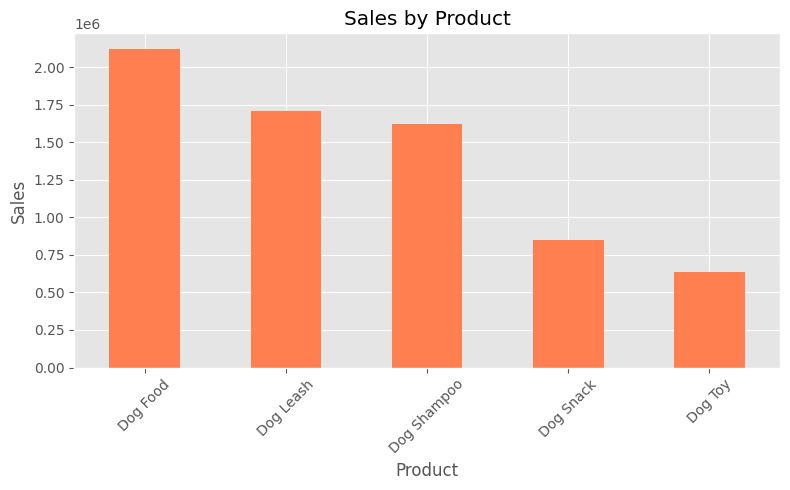

In [12]:
product_sales.plot(
    kind="bar",
    figsize=(8,5),
    color="coral"
)

plt.title("Sales by Product")
plt.xlabel("Product")
plt.ylabel("Sales")

plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig("../images/product_sales.png")

plt.show()

### Quantity Sold by Product

매출뿐 아니라 상품 판매량도 함께 분석합니다.

In [13]:
product_quantity = df.groupby("product_name")["quantity"].sum().sort_values(ascending=False)

product_quantity

product_name
Dog Snack      170
Dog Shampoo    135
Dog Leash      114
Dog Food       106
Dog Toy         91
Name: quantity, dtype: int64

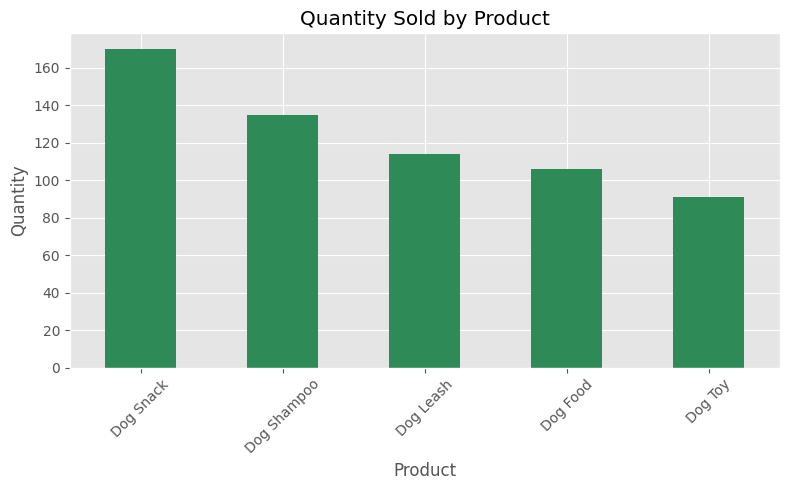

In [14]:
product_quantity.plot(
    kind="bar",
    figsize=(8,5),
    color="seagreen"
)

plt.title("Quantity Sold by Product")
plt.xlabel("Product")
plt.ylabel("Quantity")

plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig("../images/product_quantity.png")

plt.show()

### Daily Order Trend

일별 주문 수를 확인하여 주문 패턴을 분석합니다.

In [15]:
daily_orders = df.groupby("order_date")["order_id"].count()

daily_orders.head()

order_date
2024-01-01    1
2024-01-02    1
2024-01-03    1
2024-01-04    4
2024-01-05    4
Name: order_id, dtype: int64

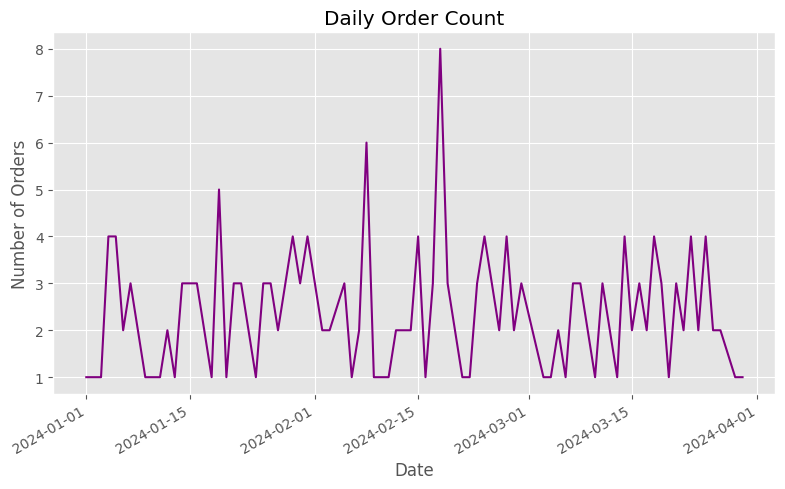

In [16]:
daily_orders.plot(
    kind="line",
    figsize=(8,5),
    color="purple"
)

plt.title("Daily Order Count")
plt.xlabel("Date")
plt.ylabel("Number of Orders")

plt.tight_layout()
plt.savefig("../images/daily_orders.png")

plt.show()

## Key Insights

- 월별 매출은 기간 동안 일정한 변동 패턴을 보인다.
- Dog Food와 Dog Leash가 높은 가격으로 인해 매출 기여도가 높다.
- Dog Snack은 판매량은 많지만 단가가 낮아 총매출은 상대적으로 낮다.
- 상품 성과를 평가할 때 판매량과 매출을 함께 고려해야 한다.

### Sales Distribution

매출 데이터의 분포를 확인하여  
주문 금액이 어떤 범위에 집중되어 있는지 분석합니다.

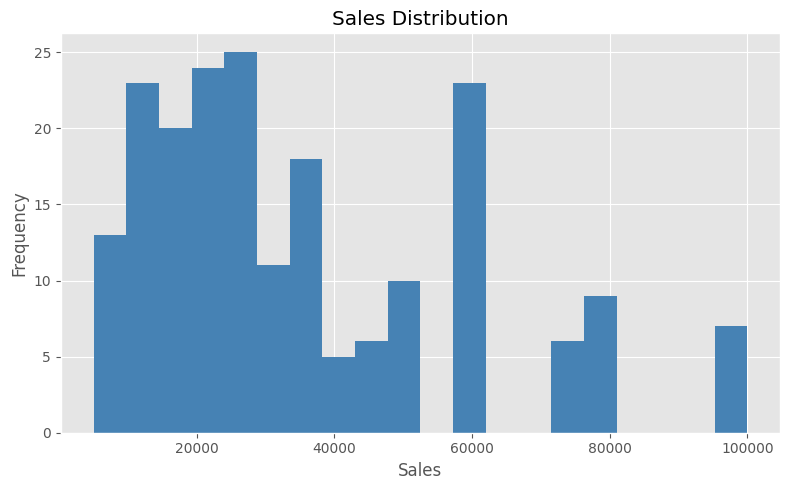

In [17]:
df["sales"].plot(
    kind="hist",
    bins=20,
    figsize=(8,5),
    color="steelblue"
)

plt.title("Sales Distribution")
plt.xlabel("Sales")
plt.ylabel("Frequency")

plt.tight_layout()
plt.savefig("../images/sales_distribution.png")

plt.show()